In [2]:
import torch
import torch.nn as nn
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer
import numpy as np
import pandas as pd
import os
import sys
import glob
import tqdm
from scipy.special import softmax
import re
from typing import List
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

os.chdir("/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis")
from sentence_splitter import split_text_into_sentences

In [3]:
sentence_length = 6

## Test using a BERT-Classification Model trained on paragraphs to classify an entire report.

**Function:** pdf -> NACE Class

In [4]:
%pwd

'/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis'

In [5]:
dataset_path = "data/datasets/german_annual_reports"
dataset_path = "data/datasets/stoxx_600_extended"
dataset_path = "data/datasets/stoxx_600"
dataset_path = "data/datasets/reports_subset_from_full_data_1"

In [6]:
over_view_df_path = os.path.join(dataset_path, os.path.basename(dataset_path) + "_overview.csv")

dataset_path_texts = os.path.join(dataset_path, "TXTs")

dataset_name = os.path.basename(dataset_path)

In [7]:
nace_classes = pd.read_csv(over_view_df_path, index_col=0, sep=",")
nace_classes.head()

,Symbol,Name,Company is Active,Company Founded Date,Country of Primary Listing Iso3,CUSIP,Date Of First Trade,Entity Country HQ,Entity Credit Parent,NACE,...,ISIN,Primary Equity Listing,Proper Name,Public Company,Region Ticker,Sec is Primary Issue,Sec Type,SEDOL,NACE_letter,Report
5789,ZW0009011041,Ariston Holdings Ltd.,1,1947.0,ZWE,V97772103,20090317.0,ZWE,@NA,1.19,...,ZW0009011041,603408,Ariston Holdings Ltd.,1.0,ARIS-ZW,1,SHARE,6034081,A,Ariston Holdings Ltd.1.pdf
35816,INE978A01027,Heritage Foods Limited,1,1992.0,IND,Y3179H146,20020117.0,IND,06FQLY-E,1.41,...,INE978A01027,BF2F40,Heritage Foods Limited,1.0,519552-IN,1,SHARE,BF2F405,A,Heritage Foods Limited1.pdf
80373,MYL7854OO002,Timberwell Bhd.,1,1996.0,MYS,Y88399103,19970516.0,MYS,05JH15-E,2.30,...,MYL7854OO002,690556,Timberwell Bhd.,1.0,7854-MY,1,SHARE,6905563,A,Timberwell Bhd.1.pdf
49813,MYQ0189OO009,Matang Bhd.,1,2015.0,MYS,Y58347108,20170117.0,MYS,@NA,1.19,...,MYQ0189OO009,BYYQB5,Matang Bhd.,1.0,0189-MY,1,SHARE,BYYQB53,A,Matang Bhd.2.pdf
73064,MYL4316OO005,Sin Heng Chan (Malaya) Bhd.,1,1962.0,MYS,Y80178109,19880324.0,MYS,05YMQ5-E,1.19,...,MYL4316OO005,681088,Sin Heng Chan (Malaya) Bhd.,1.0,4316-MY,1,SHARE,6810883,A,Sin Heng Chan (Malaya) Bhd.1.pdf


In [8]:
report_to_nace_class = nace_classes.dropna(subset=["Report"]).set_index('Report').to_dict()["NACE"]
report_to_nace_class = {report[0][:-4] + ".txt": report[1] for report in report_to_nace_class.items()}
len(report_to_nace_class)

1559

In [9]:
reports_path = glob.glob(os.path.join(dataset_path_texts, "*.txt"))
len(reports_path)

1556

In [10]:
def get_tables(lines: list): 
    tables = []
    current_table = []

    for line in lines:
        if line.strip().startswith("|"):  # line belongs to a table
            current_table.append(line.strip())
        else:
            if current_table:  # table ended
                tables.append("\n".join(current_table))
                current_table = []

    # catch last table if file ends without empty lines
    if current_table:
        tables.append("\n".join(current_table))

    return tables

def preprocess_report(pdf_path: str) -> List[str]:

    with open(pdf_path, "r") as f: 
        text = f.read()
    
    lines = text.split("\n")

    tables = get_tables(lines)

    # drop if condidtion is True
    conditions = [
        # filter images
        lambda line: line == '<!-- image -->',
        
        #filter tables 
        lambda line: (line[0] == "|" and line[-1] == "|") if len(line) > 1 else False, 

        # filter headers
        lambda line: line.strip()[0] == "#" if len(line) > 0 else True,

        # filter sentences
        lambda line: "." not in line,
        
        # more than 50% is numbers
        lambda line: sum(ch.isalpha() for ch in line) / len(line) < 0.5,

        # minimum 3 words 
        lambda line: len(re.sub(r"[^a-zA-ZäöüÄÖÜß\s]", '', line).strip().split(" ")) < 3,

        # Minimum 2 Sentences
        #lambda line: sum([0 if len(sentence.split(" ")) < 3 else 1 for sentence in split_text_into_sentences(line, "en")]) < 2

    ]
    accepted_lines = [line for line in lines if not any(condition(line) for condition in conditions)]
    accepted_lines += tables

    chunks = []

    for line in accepted_lines: 
        sentences = split_text_into_sentences(line, language='en')
        sentences = [sentence.strip() for sentence in sentences]
        sentences = [sentence for sentence in sentences if sentence != ""]
        new_chunks = [(" ".join(sentences[i:i+sentence_length])).strip() for i in range(0, len(sentences), 3)]

        chunks += new_chunks

    # if there is only one sentence in the last chunk, balance the two last chunks
    if len(split_text_into_sentences(chunks[-1], language = "en")) == 1: 
        last_two_chunks = chunks[-2] + " " + chunks[-1]
        chunks[-2] = last_two_chunks[0:(len(last_two_chunks) + 1) // 2]
        chunks[-1] = last_two_chunks[(len(last_two_chunks) + 1) // 2: (len(last_two_chunks)) - (len(last_two_chunks) + 1) // 2]

    chunks = [re.sub(r'\b\d+\.\d+\b', '', chunk) for chunk in chunks]
    chunks = [re.sub(r"[^a-zA-ZäöüÄÖÜß.\s]", '', chunk) for chunk in chunks]
    chunks = [re.sub(r"\s+", " ", chunk) for chunk in chunks]
    chunks = [re.sub(r'\.{2,}', " ", chunk) for chunk in chunks]
    chunks = [re.sub(r'^\d+\.\s*', " ", chunk) for chunk in chunks]
    chunks = [chunk.lower() for chunk in chunks]
    chunks = [chunk.strip() for chunk in chunks]

    return chunks

# Playground

In [11]:
chunks = preprocess_report(pdf_path=reports_path[0])
len(chunks)

2249

In [12]:
model_path = "results/BERT_models/results__new_approach_data__num_layers_2bert-base-uncased__train_full_model__some_labels/checkpoint-15990"
model_path = "results/BERT_models/results_null_classifiers__cos_thres_0.5__bert-base-uncased__train_full_model__some_labels/checkpoint-2331"

In [13]:
import os
import torch
import torch.nn as nn
from transformers import AutoConfig, AutoModelForSequenceClassification
from safetensors.torch import load_file  # comes with HF if safetensors installed

def load_custom_bert_from_checkpoint(ckpt_path: str):
    # 1. Load the saved config (includes custom_hidden, custom_num_layers)
    config = AutoConfig.from_pretrained(ckpt_path)

    # 2. Build a model from config (bare BertForSequenceClassification)
    model = AutoModelForSequenceClassification.from_config(config)

    # 3. Rebuild the SAME classifier architecture as in training
    hidden = getattr(config, "custom_hidden", 512)  # fallback if not in config
    num_layers = getattr(config, "custom_num_layers", 2)

    layers = []
    for i in range(num_layers):
        in_dim = config.hidden_size if i == 0 else hidden
        layers.append(nn.Linear(in_dim, hidden))
        layers.append(nn.GELU())
        layers.append(nn.Dropout(0.2))

    layers.append(nn.Linear(hidden, config.num_labels))
    model.classifier = nn.Sequential(*layers)

    # 4. Load weights from model.safetensors
    state_dict = load_file(os.path.join(ckpt_path, "model.safetensors"))
    model.load_state_dict(state_dict, strict=True)  # will fail loudly if mismatch

    # 5. Inference mode
    model.eval()
    return model

In [14]:
ckpt_path = "results/BERT_models/results_null_classifiers__cos_thres_0.5__bert-base-uncased__train_full_model__some_labels/checkpoint-2331"
ckpt_path = "results/BERT_models/results_null_classifiers__cos_thres_0.5__bert-base-uncased__train_full_model__some_labels/checkpoint-2331"
ckpt_path = "results/BERT_models/results__new_approach_data__num_layers_2bert-base-uncased__train_full_model__some_labels/checkpoint-15990"
model = load_custom_bert_from_checkpoint(ckpt_path)

tokenizer = AutoTokenizer.from_pretrained(ckpt_path) 

def BERT_classification_chunk(chunk: str, model, tokenizer):

    inputs = tokenizer(chunk, return_tensors="pt", truncation=True)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits.squeeze(0)

    return logits

In [20]:
chunk = "This section includes the provision of passenger or freight transport, whether scheduled or not, by rail, pipeline, road, water or air and associated activities such as terminal and parking facilities, cargo handling, storage etc. Included in this section is the rental of transport equipment with driver or operator. Also included are postal and courier activities."
chunk = "'chairman of the board of directors hannover re bermuda ltd. hamilton bermuda'"

label_scores = BERT_classification_chunk(chunk, model, tokenizer)

label_scores = {
    model.config.id2label[i]: label_scores[i].item()
    for i in range(label_scores.size(0))
}

df_label_scores = pd.DataFrame.from_dict(label_scores, orient="index")
df_label_scores = df_label_scores.sort_values(0, ascending=False)
df_label_scores_ = df_label_scores.sort_values(0, ascending=False)
df_label_scores[0] = softmax(df_label_scores[0])
df_label_scores

,0
K,0.822482
NO_CLASS,0.169657
N,0.002804
G,0.000977
L,0.000918
H,0.000817
M,0.000438
I,0.000405
F,0.000394
D,0.000268


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, 'H'),
  Text(1, 0, 'NO_CLASS'),
  Text(2, 0, 'G'),
  Text(3, 0, 'K'),
  Text(4, 0, 'F'),
  Text(5, 0, 'N'),
  Text(6, 0, 'I'),
  Text(7, 0, 'D'),
  Text(8, 0, 'C'),
  Text(9, 0, 'E'),
  Text(10, 0, 'B'),
  Text(11, 0, 'L'),
  Text(12, 0, 'Q'),
  Text(13, 0, 'M'),
  Text(14, 0, 'P'),
  Text(15, 0, 'A'),
  Text(16, 0, 'J')])

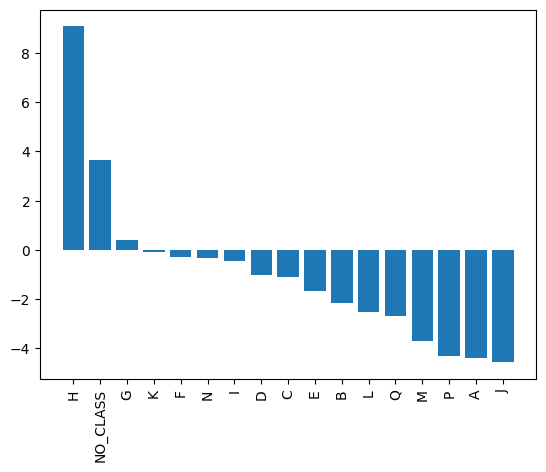

In [16]:
plt.bar(df_label_scores_.index, df_label_scores_[0])
plt.xticks(rotation=90)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, 'H'),
  Text(1, 0, 'NO_CLASS'),
  Text(2, 0, 'G'),
  Text(3, 0, 'K'),
  Text(4, 0, 'F'),
  Text(5, 0, 'N'),
  Text(6, 0, 'I'),
  Text(7, 0, 'D'),
  Text(8, 0, 'C'),
  Text(9, 0, 'E'),
  Text(10, 0, 'B'),
  Text(11, 0, 'L'),
  Text(12, 0, 'Q'),
  Text(13, 0, 'M'),
  Text(14, 0, 'P'),
  Text(15, 0, 'A'),
  Text(16, 0, 'J')])

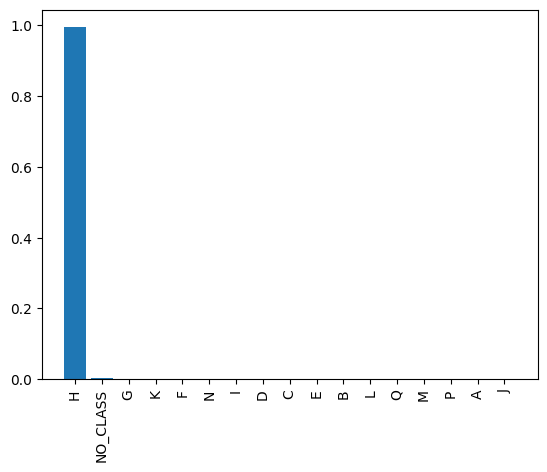

In [17]:
plt.bar(df_label_scores.index, df_label_scores[0])
plt.xticks(rotation=90)

# HIEr

In [17]:
def classify_report(chunks: list, 
                    model: AutoModelForSequenceClassification,
                    tokenizer: AutoTokenizer,
                    result_path: str,
                    report_path: str, 
                    level: int = None,
                    **kwags) -> dict:
    """
    1. Preprocess a report into text chunks.
    2. Classify each chunk with the BERT model.
    3. Aggregate logits over all chunks and return {label: logit_score}.
    """

    # 1) Preprocess report -> list of chunks
    chunks = [chunk for chunk in chunks if chunk.strip()]

    # Safety: no chunks -> empty result
    if len(chunks) == 0:
        return {}

    model.eval()
    chunk_logits = []   
    sentence_classification = []

    for chunk in tqdm.tqdm(chunks[:40]):

        logits = BERT_classification_chunk(chunk, 
                                           model=model, 
                                           tokenizer=tokenizer)
        chunk_logits.append(logits)
        
        label_scores = {
            model.config.id2label[i]: logits[i].item()
            for i in range(logits.size(0))
        }
        sentence_classification.append(label_scores)
        print(max(softmax(logits)))

    if len(chunk_logits) == 0:
        return {}

    # 3) Aggregate logits over all chunks (mean over chunks)
    stacked = torch.stack(chunk_logits, dim=0)  # (num_chunks, num_labels)
    avg_logits = stacked.mean(dim=0)            # (num_labels,)

    # Map to human-readable labels
    label_scores = {
        model.config.id2label[i]: avg_logits[i].item()
        for i in range(avg_logits.size(0))
    }

    sentence_classification = pd.DataFrame(sentence_classification)
    sentence_classification["Sentences"] = chunks[:40]

    os.makedirs(os.path.join(result_path, os.path.basename(report_path)), exist_ok=True)
    sentence_classification.to_csv(os.path.join(result_path, os.path.basename(report_path), os.path.basename(report_path) + "_classifications.csv"))

    return label_scores, sentence_classification

In [18]:
reports_path[0]

'data/datasets/reports_subset_from_full_data_1/TXTs/Heritage Foods Limited1.txt'

In [19]:
chunks = preprocess_report(pdf_path=reports_path[0])   
chunks = preprocess_report(pdf_path="data/datasets/stoxx_600/TXTs/Hannover Rueck SE1.txt")   

# Example usage on the first report:
report_scores, sentence_classification = classify_report(chunks, model, tokenizer, result_path="../../results/BERT_classification/test_1", report_path=reports_path[0])
print(report_scores)

 10%|███████                                                               | 4/40 [00:00<00:00, 36.85it/s]

0.8370906
0.94203967
0.7127399
0.947367
0.5107548
0.9516341
0.73314786
0.94527024


 35%|████████████████████████▏                                            | 14/40 [00:00<00:00, 43.08it/s]

0.90081847
0.8430754
0.93746954
0.96312547
0.93273705
0.92703855
0.9330069
0.7322025
0.8049739


 57%|███████████████████████████████████████▋                             | 23/40 [00:00<00:00, 37.21it/s]

...

0.98025334
0.9328581
0.98828876
0.9966456
0.6419053
0.8439453
0.98408395
0.95570165


 88%|████████████████████████████████████████████████████████████▍        | 35/40 [00:00<00:00, 34.02it/s]

0.9832197
0.6596681
0.4841953
0.99460715
0.9828949
0.5104646
0.98790354


100%|█████████████████████████████████████████████████████████████████████| 40/40 [00:01<00:00, 35.68it/s]

0.5502604
0.4972758
{'F': -1.612402319908142, 'C': -3.0638813972473145, 'NO_CLASS': 4.167400360107422, 'M': 0.23852474987506866, 'L': -1.0958778858184814, 'H': -1.3027832508087158, 'P': -1.309874176979065, 'G': -0.5231086015701294, 'D': -1.69634211063385, 'J': -1.4870660305023193, 'Q': -1.8678381443023682, 'I': 0.7303979396820068, 'N': 0.6963341236114502, 'E': -2.314009189605713, 'K': 2.1273465156555176, 'A': -2.3429996967315674, 'B': -2.8204405307769775}


In [22]:
chunks

['chairman of the board of directors hannover re bermuda ltd. hamilton bermuda',
 'member of the board of directors hannover life reassurance company of america bermuda ltd. hamilton bermuda',
 'chairman of the board of directors argenta holdings limited london united kingdom chairman of the board of directors glencar insurance company orlando usa chairman of the board of directors hannover re services usa inc. illinois usa member of the board of directors argenta syndicate management limited london united kingdom member of the board of directors hdi global specialty se hannover germany',
 'chairman of the board of directors hannover retakaful b.s.c. c manama bahrain deputy chairman of the board of directors hannover life re of australasia ltd sydney australia deputy chairman of the board of directors hannover reinsurance group africa pty ltd. johannesburg south africa deputy chairman of the board of directors hannover re south africa limited johannesburg south africa member of the boa

In [20]:
sentence_classification

,F,C,NO_CLASS,M,L,H,P,G,D,J,Q,I,N,E,K,A,B,Sentences
0,-1.064831,-4.141967,4.926917,-0.906978,-0.034948,-0.287476,-2.751506,-0.098598,-1.333987,-4.315241,-1.480802,-1.114367,0.739279,-1.544190,6.612047,-2.397510,-1.841711,chairman of the board of directors hannover re...
1,-1.440888,-4.006747,3.926036,-0.135285,0.117546,-0.343094,-3.166182,-0.457603,-1.299826,-3.825010,-1.832833,-1.514151,1.239217,-1.469093,6.866582,-2.122139,-1.495092,member of the board of directors hannover life...
2,-0.713080,-3.557070,4.727685,-1.503989,-0.125293,-0.062071,-2.332094,0.468494,-0.955708,-4.324084,-1.201696,-0.968128,0.130693,-1.264105,5.697380,-2.157110,-1.461140,chairman of the board of directors argenta hol...
3,-1.440599,-4.027958,3.859876,-0.343408,0.256701,-0.274721,-3.158968,-0.201391,-1.259008,-3.937404,-1.754612,-1.673607,1.042935,-1.536192,6.905101,-2.077481,-1.460498,chairman of the board of directors hannover re...
4,-0.322047,-3.318028,5.163466,-1.750044,-0.521167,-0.137380,-2.251975,0.573204,-0.655043,-4.468990,-1.190237,-0.928906,-0.118965,-1.221196,5.077692,-2.429816,-1.488839,chairman of the board of directors hannover fi...
5,-1.428061,-3.857278,3.561125,-0.171055,0.211452,-0.301639,-3.142148,-0.287136,-1.198397,-3.750758,-1.804722,-1.681639,1.106149,-1.382143,6.751012,-1.958714,-1.255482,chairman of the board of directors hannover fi...
6,-0.580106,-4.097226,5.176115,-1.371877,0.196495,-0.110734,-2.559623,-0.004736,-1.301471,-4.512691,-1.550022,-0.840218,0.289737,-1.520743,6.224162,-2.485093,-1.808145,chairman of the board of directors bristol re ...
7,-1.447240,-4.015617,3.890544,-0.162010,0.128028,-0.333655,-3.186244,-0.404056,-1.306008,-3.844461,-1.833229,-1.558822,1.240064,-1.489405,6.897254,-2.114489,-1.487246,chairman of the board of directors hannover li...
8,-1.202372,-4.139740,4.594755,-0.513330,-0.138226,-0.240466,-3.020534,-0.352197,-1.354246,-4.113697,-1.752401,-1.285985,1.134827,-1.535502,6.875532,-2.359658,-1.728162,chairman of the board of directors kubera insu...
9,-1.096676,-4.158362,4.907681,-0.790764,-0.004556,-0.302889,-2.786503,-0.243418,-1.360201,-4.248434,-1.549803,-1.058264,0.811454,-1.540607,6.638890,-2.394379,-1.852048,member of the board of directors hannover re b...


In [76]:
result_path="../../results/BERT_classification/test_1"
report_path = reports_path[0]
os.path.join(result_path, os.path.basename(report_path), os.path.basename(report_path) + "_classifications.csv")

'../../results/BERT_classification/test_1/Hannover Rueck SE1.txt/Hannover Rueck SE1.txt_classifications.csv'

In [23]:
scores = sentence_classification.columns.drop("Sentences")
sentence_classification[scores].apply(lambda x: softmax(x), axis=1)[0]

array([3.87923917e-04, 1.78798287e-05, 1.55213608e-01, 4.54256682e-04,
       1.08647344e-03, 8.44009817e-04, 7.18179294e-05, 1.01947440e-03,
       2.96383318e-04, 1.50352756e-05, 2.55913257e-04, 3.69176038e-04,
       2.35646883e-03, 2.40194900e-04, 8.37090679e-01, 1.02322586e-04,
       1.78382400e-04])

In [20]:
df_report_scores = pd.DataFrame.from_dict(label_scores, orient="index")
df_report_scores = df_report_scores.sort_values(0, ascending=False)
df_report_scores

,0
H,9.083044
NO_CLASS,3.667672
G,0.382561
K,-0.078842
F,-0.305915
N,-0.344003
I,-0.451169
D,-1.021317
C,-1.096125
E,-1.655065


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, 'H'),
  Text(1, 0, 'NO_CLASS'),
  Text(2, 0, 'G'),
  Text(3, 0, 'K'),
  Text(4, 0, 'F'),
  Text(5, 0, 'N'),
  Text(6, 0, 'I'),
  Text(7, 0, 'D'),
  Text(8, 0, 'C'),
  Text(9, 0, 'E'),
  Text(10, 0, 'B'),
  Text(11, 0, 'L'),
  Text(12, 0, 'Q'),
  Text(13, 0, 'M'),
  Text(14, 0, 'P'),
  Text(15, 0, 'A'),
  Text(16, 0, 'J')])

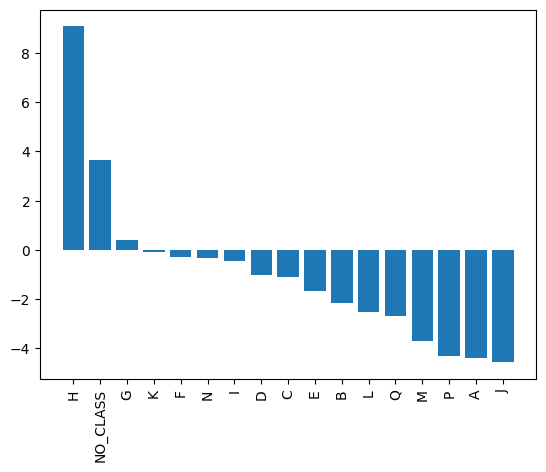

In [21]:
plt.bar(df_report_scores.index, df_report_scores[0])
plt.xticks(rotation=90)